import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


data collection and analysis

In [25]:
data=pd.read_csv('Mall_Customers.csv')

In [26]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
data.shape

(200, 5)

In [28]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [30]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


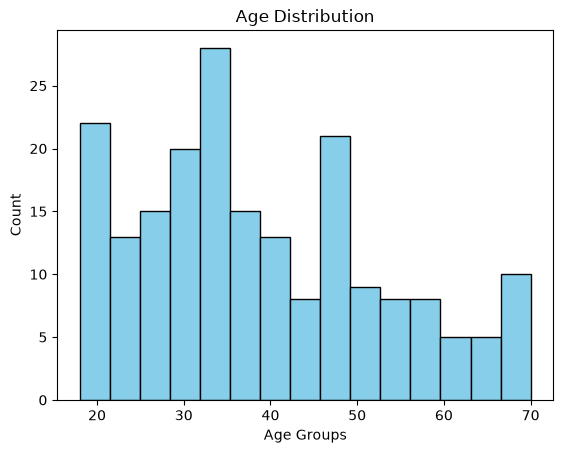

In [31]:

plt.hist(data['Age'], bins=15, edgecolor='black', color='skyblue')
plt.title('Age Distribution')
plt.xlabel('Age Groups')
plt.ylabel('Count')
plt.show()


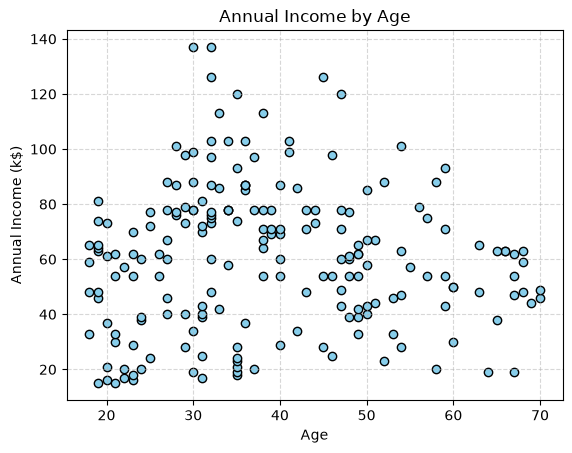

In [32]:

plt.scatter(data['Age'], data['Annual Income (k$)'], color='skyblue', edgecolor='black')
plt.title('Annual Income by Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

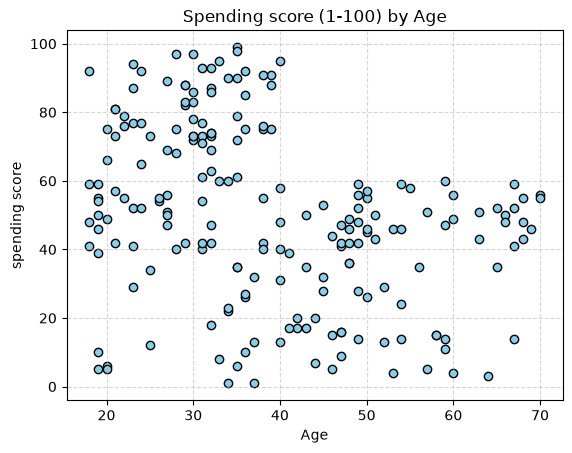

In [33]:

plt.scatter(data['Age'], data['Spending Score (1-100)'], color='skyblue', edgecolor='black')
plt.title('Spending score (1-100) by Age')
plt.xlabel('Age')
plt.ylabel('spending score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [48]:
X = data[[ 'Annual Income (k$)', 'Spending Score (1-100)']].values

In [49]:
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

scaling data for better performance

In [50]:
scaler=StandardScaler()
X_scaled = scaler.fit_transform(X)



In [51]:
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

choosing the number of clusters
within cluster sum of square (wcss)

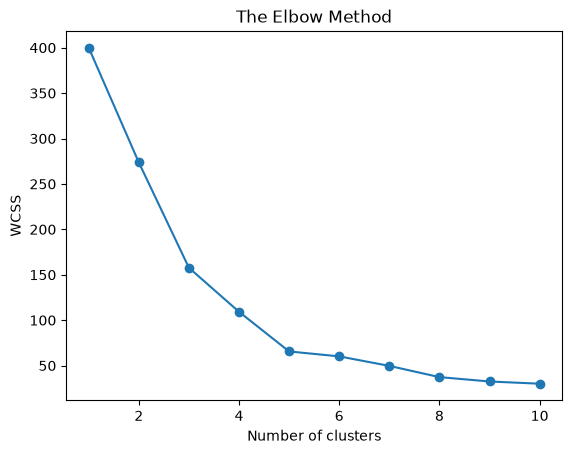

In [52]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

so the optimum clusters are 5

In [53]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)

Y=kmeans.fit_predict(X_scaled)


In [54]:
print(Y)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


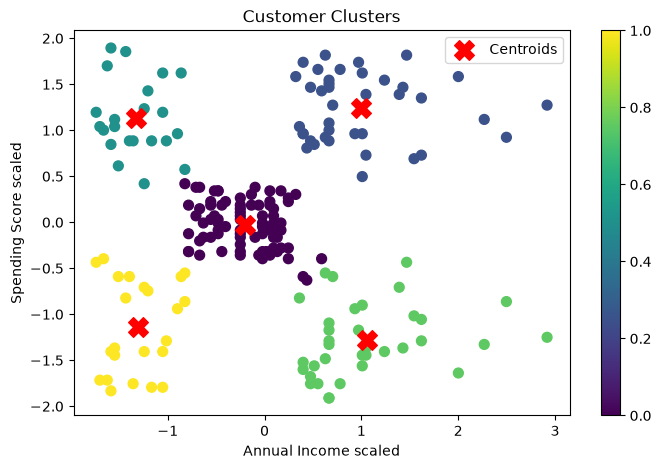

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=Y, cmap='viridis', s=50)
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('Customer Clusters')
plt.xlabel('Annual Income scaled')
plt.ylabel('Spending Score scaled')
plt.colorbar()
plt.legend()
plt.show()

In [57]:
data['Cluster'] = Y
cluster_profile = data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Count'] = data['Cluster'].value_counts().sort_index()
cluster_profile['Percentage (%)'] = (cluster_profile['Count'] / len(Y) * 100).round(2)
print(cluster_profile)

         Annual Income (k$)  Spending Score (1-100)  Count  Percentage (%)
Cluster                                                                   
0                      55.3                    49.5     81            40.5
1                      86.5                    82.1     39            19.5
2                      25.7                    79.4     22            11.0
3                      88.2                    17.1     35            17.5
4                      26.3                    20.9     23            11.5



# Conclusion

 Using K-Means clustering on **Annual Income** and **Spending Score**, customers were segmented 
 into 5 distinct groups. The elbow method confirmed k=5 as optimal, with WCSS dropping sharply 
 up to 5 clusters and flattening out afterward.

 ### Cluster Profiles

 | Cluster | Income | Spending | Segment |
 |---------|--------|----------|---------|
 | Center (purple) | Average | Average | Standard customers — moderate income, moderate spending |
 | Top-left (teal) | Low | High | Careful spenders on a budget but enthusiastic shoppers |# | Top-right (blue) | High | High | **Target segment** — high income and high spending, most valuable customers |
 | Bottom-left (yellow) | Low | Low | Cautious customers — limited income and limited spending |
 | Bottom-right (green) | High | Low | High income but low spending — potential for targeted engagement |

 ### Business Recommendations
 - **High income, high spending (blue)**: Prioritize for loyalty programs and premium offerings — 
   they already spend freely and have room to spend more
 - **High income, low spending (green)**: Investigate why they aren't spending — targeted promotions 
   or personalized recommendations could unlock significant revenue
 - **Low income, high spending (teal)**: Engage with value-driven offers, discounts, and 
   budget-friendly bundles to retain their loyalty
 - **Low income, low spending (yellow)**: Lower marketing priority — focus retention budget elsewhere
 - **Average/average (purple)**: Largest group; general marketing campaigns work well here

 ### Limitations
 - Age was tested as a third clustering feature but did not meaningfully improve interpretability, 
   so the final model uses only Income and Spending Score
 - Clusters are based on a single mall's customer data and may not generalize to other locations
 - K-Means assumes roughly spherical, similarly-sized clusters, which may oversimplify real customer behavior